# Provada Analysis Example Notebook ⭐

This notebook demonstrates how to analyze and visualize provada run results.

It covers how to:
- Load trajectory data with sequence scores
- Create static scatter plots with gradient coloring
- Generate animated MOV videos showing trajectory evolution
- Create multi-plot animations comparing different score combinations

## Setup

First, let's import the necessary modules and set up our environment.

In [1]:
import sys
from pathlib import Path

# Add parent directory to path so we can import the analyze module
script_dir = Path.cwd()
parent_dir = script_dir.parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import matplotlib.pyplot as plt
from analyze import (
    load_run_data,
    show_trajectory_plot,
    create_trajectory_animation,
    create_multi_trajectory_animation,
)

# Enable inline plotting
%matplotlib inline

print("Setup complete!")

Setup complete!


## Configure Your Result Directory

Set the path to your provada run results directory here.

In [2]:
# Update this path to point to your results directory
result_dir = "../results/renin_localization_balrog_a7ea7"

# Extract result name for organized output
result_name = Path(result_dir).name

print(f"Result directory: {result_dir}")
print(f"Result name: {result_name}")

Result directory: ../results/renin_localization_balrog_a7ea7
Result name: renin_localization_balrog_a7ea7


## Load Run Data

Load the trajectory data and merge it with sequence scores.

In [3]:
print("Loading run data...")
df = load_run_data(result_dir)

print(f"\nLoaded {len(df)} trajectory points")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Loading run data...

Loaded 100000 trajectory points

Columns: ['sequence_hash', 'selected_count', 'accepted', 'iteration', 'sequence_similarity', 'localization_prob', 'sap_score', 'rosetta_energy_score', 'localization_prob_normalized', 'localization_prob_delta', 'sap_score_normalized', 'sap_score_delta', 'sequence_similarity_normalized', 'sequence_similarity_delta', 'rosetta_energy_score_normalized', 'rosetta_energy_score_delta', 'SCORE']

First few rows:


,sequence_hash,selected_count,accepted,iteration,sequence_similarity,localization_prob,sap_score,rosetta_energy_score,localization_prob_normalized,localization_prob_delta,sap_score_normalized,sap_score_delta,sequence_similarity_normalized,sequence_similarity_delta,rosetta_energy_score_normalized,rosetta_energy_score_delta,SCORE
0,09c2fd8a20e7653e7369a0ee41e75fb73a7a08ef4c75a1...,0,1,0,0.914706,0.079362,201.526306,4.071827,0.079362,0.043666,0.933355,0.739077,0.914706,-0.085294,1.000000,0.210995,0.479497
1,71c67f9b001178ce5550fd4453a0f9342bffd726b11f81...,0,1,0,0.902941,0.090789,185.243912,5.319104,0.090789,0.055094,1.000000,0.805722,0.902941,-0.097059,0.778894,-0.010111,0.517444
2,08b57fe043f15767d2fcbf833880ad388ae62fc1550ccb...,0,1,0,0.897059,0.107786,202.272079,10.339637,0.107786,0.072091,0.897986,0.703707,0.897059,-0.102941,0.000000,-0.789005,0.434472
3,336a496bd94e28156aacae45417428b96a6ecdcd43870d...,0,1,0,0.905882,0.082604,211.155289,2.108115,0.082604,0.046908,0.476689,0.282411,0.905882,-0.094118,1.000000,0.210995,0.194818
4,27c278313a98cb9679352f3a65c759a7a727613baed964...,0,1,0,0.905882,0.059351,187.748810,4.689856,0.059351,0.023656,1.000000,0.805722,0.905882,-0.094118,0.913982,0.124977,0.511933


## Basic Statistics

Let's look at some basic statistics about the run.

In [4]:
print("Dataset Statistics:")
print(f"Total points: {len(df):,}")
print(f"Iterations: {df['iteration'].min()} to {df['iteration'].max()}")
print(f"Unique sequences: {df['sequence_hash'].nunique():,}")
print(f"\nScore ranges:")
print(df[['localization_prob', 'sequence_similarity', 'sap_score', 'rosetta_energy_score']].describe())

Dataset Statistics:
Total points: 100,000
Iterations: 0 to 499
Unique sequences: 81,750

Score ranges:
       localization_prob  sequence_similarity      sap_score  \
count      100000.000000        100000.000000  100000.000000   
mean            0.719275             0.722182     189.246395   
std             0.083154             0.013467       7.889708   
min             0.035898             0.697059     150.846756   
25%             0.693800             0.717647     183.946365   
50%             0.733745             0.720588     189.010315   
75%             0.769395             0.723529     194.137985   
max             0.811762             0.935294     239.142761   

       rosetta_energy_score  
count         100000.000000  
mean               4.753872  
std                1.823462  
min               -0.065732  
25%                3.627998  
50%                4.558410  
75%                5.775611  
max               38.074674  


## Static Trajectory Plot

Create a scatter plot showing the full trajectory with gradient coloring by iteration.

Creating trajectory plot...


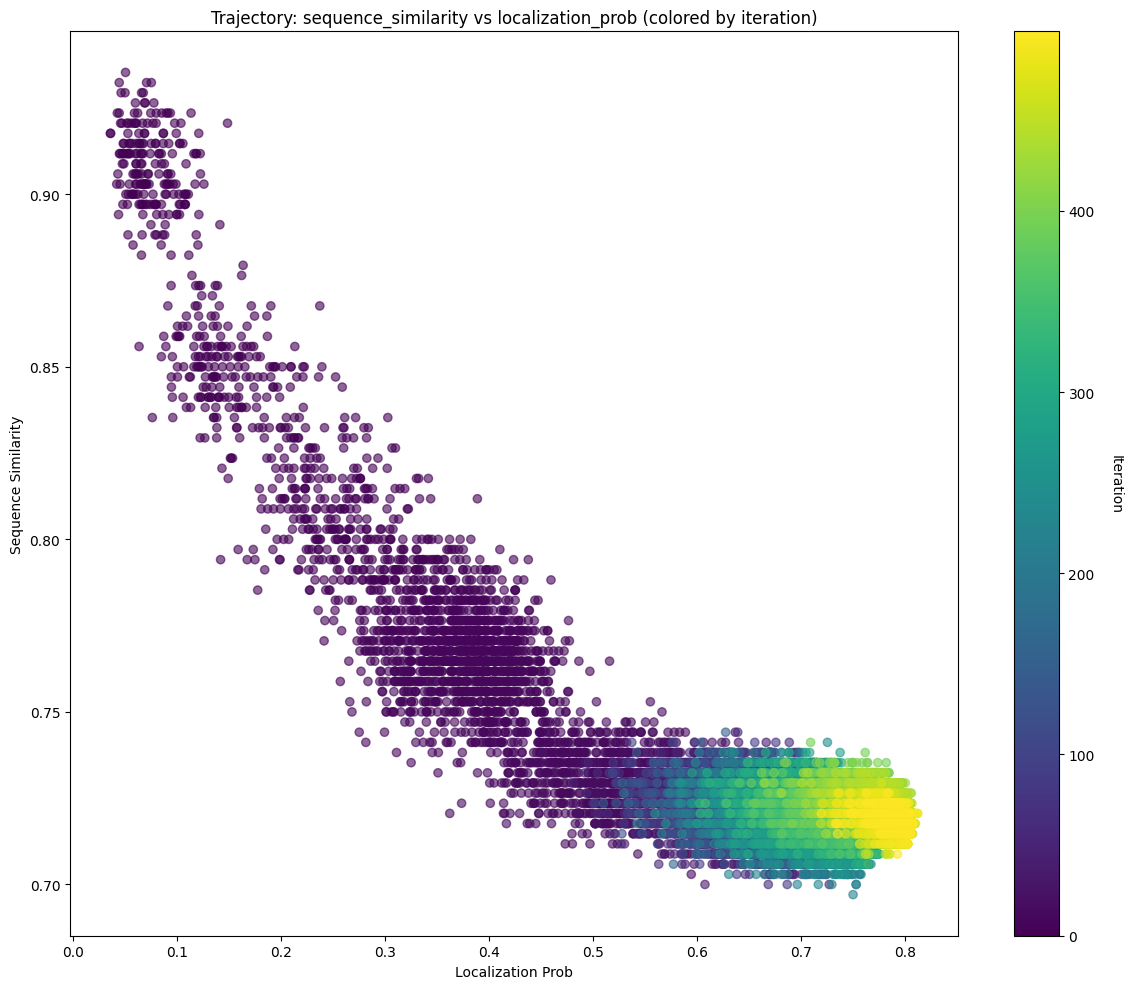

In [5]:
print("Creating trajectory plot...")
fig = show_trajectory_plot(
    df,
    x="localization_prob",
    y="sequence_similarity",
    use_gradient=True,
    cmap="viridis",
    figsize=(12, 10),
)
plt.show()

## Explore Different Colormaps

Try different colormaps to find the one that best visualizes your data.

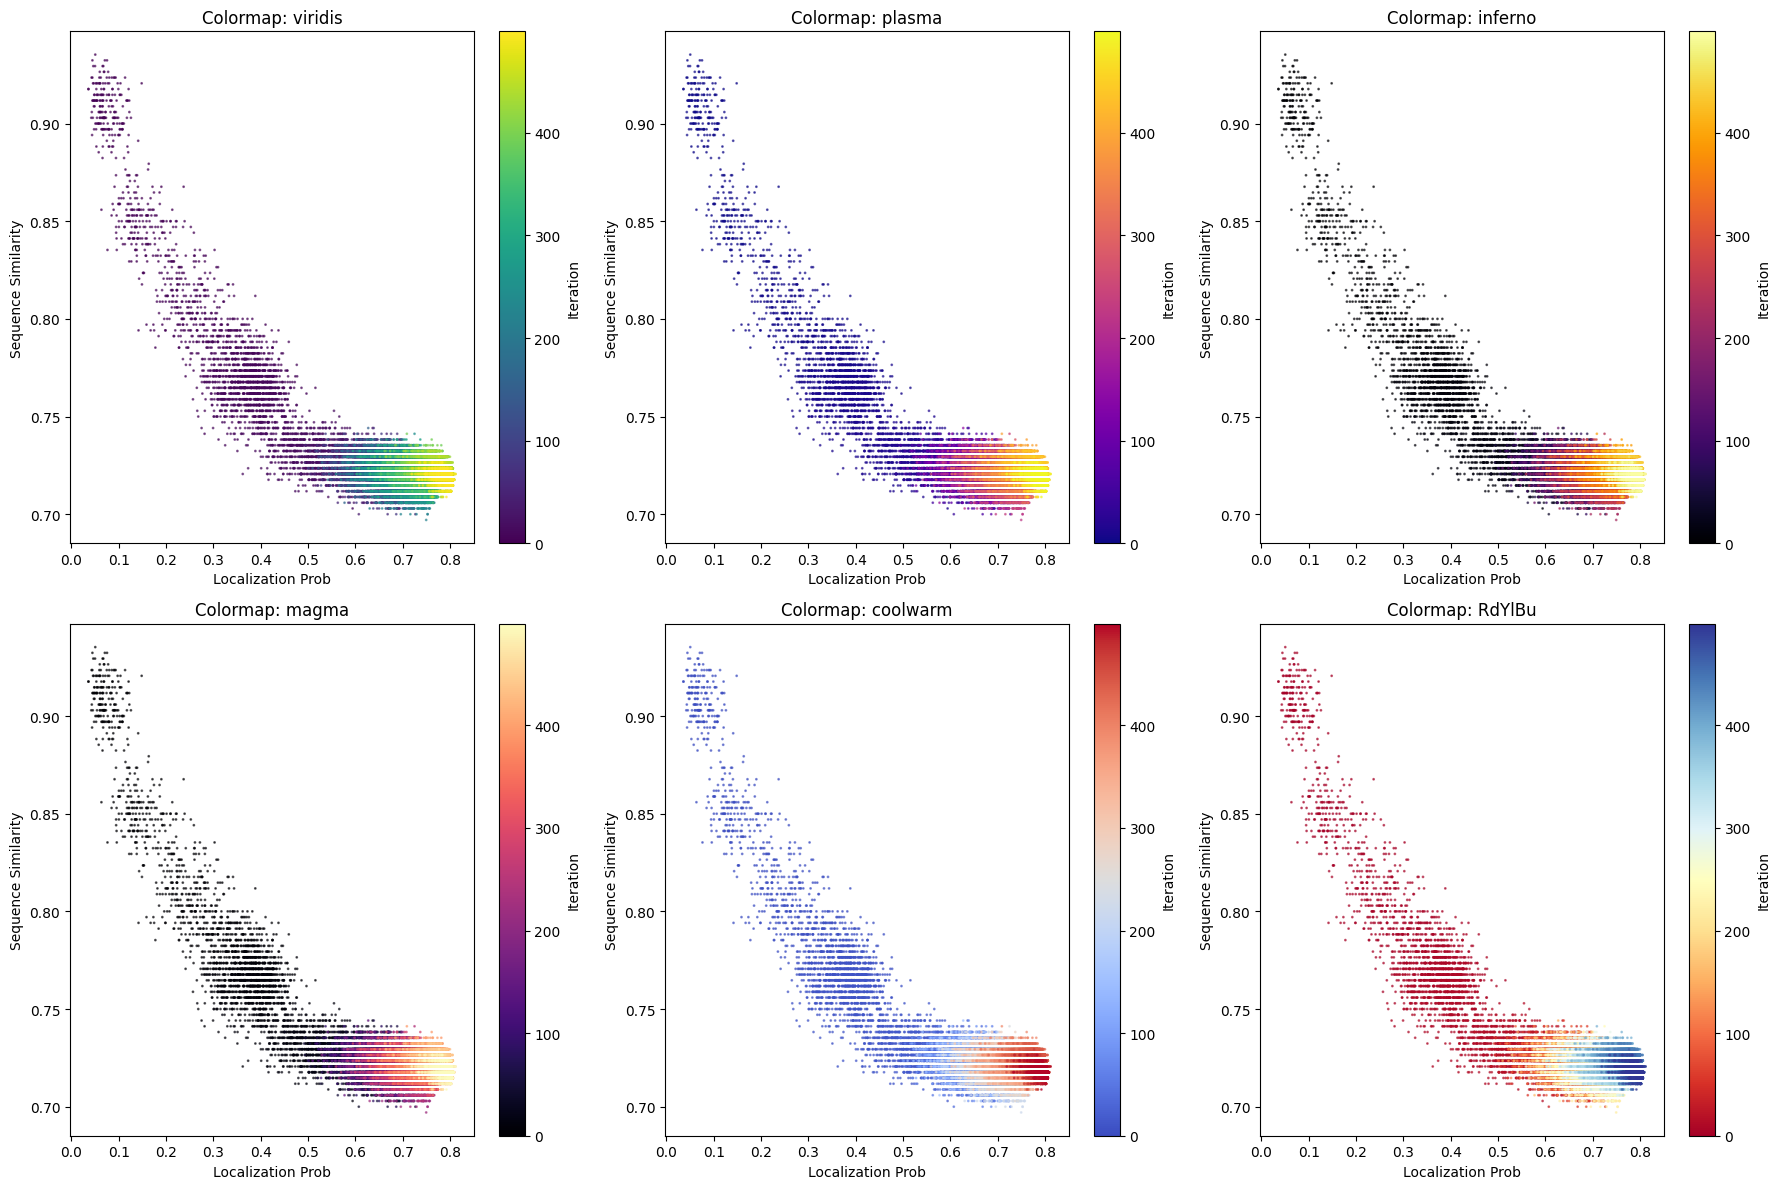

In [6]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

colormaps = ["viridis", "plasma", "inferno", "magma", "coolwarm", "RdYlBu"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

hue_data = df["iteration"]
norm = Normalize(vmin=hue_data.min(), vmax=hue_data.max())

for ax, cmap in zip(axes, colormaps):
    ax.scatter(
        df["localization_prob"],
        df["sequence_similarity"],
        c=hue_data,
        cmap=cmap,
        alpha=0.6,
        norm=norm,
        s=1,  # Small point size for large datasets
    )
    ax.set_xlabel("Localization Prob")
    ax.set_ylabel("Sequence Similarity")
    ax.set_title(f"Colormap: {cmap}")
    
    # Add colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    plt.colorbar(sm, ax=ax, label="Iteration")

plt.tight_layout()
plt.show()

## Create Animated Trajectory (Linear Distribution)

Generate an animated MOV video showing how the trajectory evolved over iterations.

**Note:** This will take 1-2 minutes to render. The video will be saved to `analyze/output/{result_name}/trajectory_animation.mov`

In [7]:
print("Creating animation with linear frame distribution...")
print("This may take 1-2 minutes...\n")

output_path = create_trajectory_animation(
    df,
    x="localization_prob",
    y="sequence_similarity",
    output_path="trajectory_linear.mov",
    result_name=result_name,
    fps=30,
    cmap="plasma",
    linear_distribution=True,  # Even distribution across iterations
)

print(f"\nAnimation saved to: {output_path}")

Creating animation with linear frame distribution...
This may take 1-2 minutes...



Rendering frames: 100%|██████████| 95/95 [01:45<00:00,  1.11s/frame]


Animation saved to: /raid/projects/viggiano/codebases/provada-dev/analyze/output/renin_localization_balrog_a7ea7/trajectory_linear.mov


## Create Animated Trajectory (Nonlinear Distribution)

Create another animation with more frames allocated to early iterations where trajectories typically change more.

**Note:** This uses a power function (0.6) to focus more frames on the beginning of the trajectory.

In [8]:
print("Creating animation with nonlinear frame distribution...")
print("This focuses more frames on early iterations...\n")

output_path = create_trajectory_animation(
    df,
    x="localization_prob",
    y="sequence_similarity",
    output_path="trajectory_early_focus.mov",
    result_name=result_name,
    fps=30,
    cmap="plasma",
    linear_distribution=False,  # More frames for early iterations
)

print(f"\nAnimation saved to: {output_path}")

Creating animation with nonlinear frame distribution...
This focuses more frames on early iterations...



Rendering frames: 100%|██████████| 95/95 [02:03<00:00,  1.30s/frame]


Animation saved to: /raid/projects/viggiano/codebases/provada-dev/analyze/output/renin_localization_balrog_a7ea7/trajectory_early_focus.mov


## Multi-Plot Animation

Create a side-by-side animation showing multiple score relationships simultaneously.

**Note:** This will take longer (3-5 minutes) as it renders multiple plots per frame.

In [9]:
print("Creating multi-plot animation...")
print("This may take 3-5 minutes...\n")

output_path = create_multi_trajectory_animation(
    df,
    plot_configs=[
        ("localization_prob", "sequence_similarity"),
        ("localization_prob", "sap_score_normalized"),
        ("sequence_similarity", "sap_score_normalized"),
    ],
    output_path="multi_trajectory.mov",
    result_name=result_name,
    fps=30,
    cmap="viridis",
)

print(f"\nMulti-plot animation saved to: {output_path}")

Creating multi-plot animation...
This may take 3-5 minutes...



Rendering frames: 100%|██████████| 95/95 [05:54<00:00,  3.73s/frame]


Multi-plot animation saved to: /raid/projects/viggiano/codebases/provada-dev/analyze/output/renin_localization_balrog_a7ea7/multi_trajectory.mov


## Custom Analysis: Score Distributions

Let's look at how scores evolved over iterations.

/tmp/ipykernel_2019673/800146079.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('iteration_bin').agg({


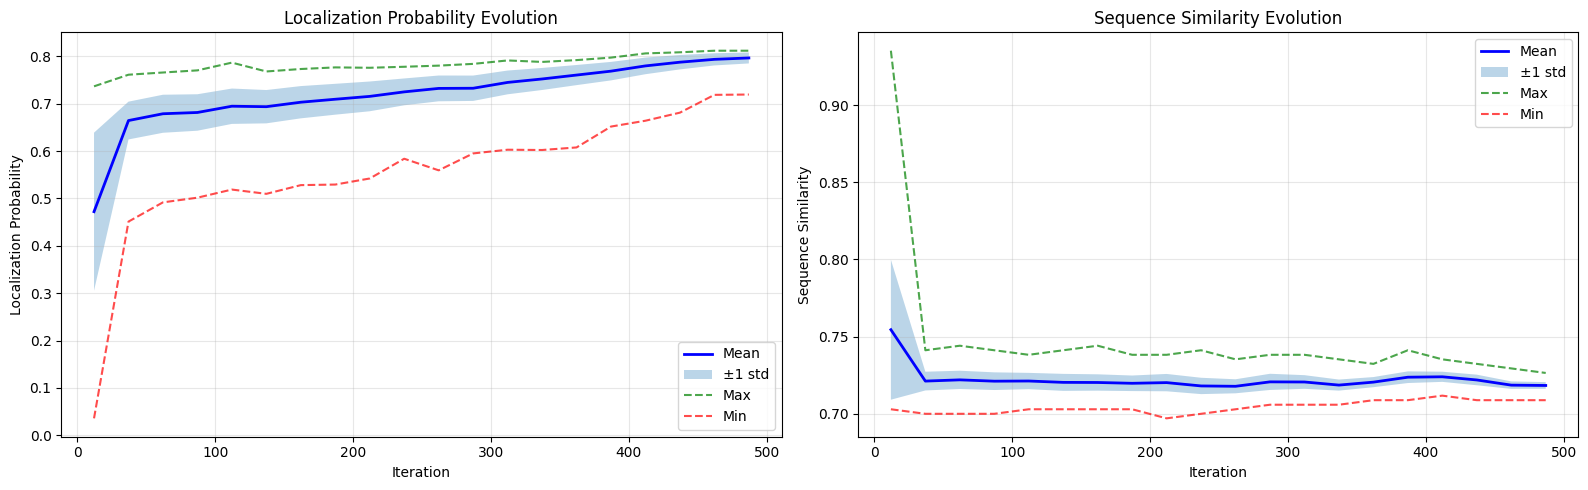

In [10]:
import numpy as np
import pandas as pd

# Bin iterations for clearer visualization
num_bins = 20
df['iteration_bin'] = pd.cut(df['iteration'], bins=num_bins)

# Calculate statistics per bin
binned_stats = df.groupby('iteration_bin').agg({
    'localization_prob': ['mean', 'std', 'min', 'max'],
    'sequence_similarity': ['mean', 'std', 'min', 'max'],
    'iteration': 'mean',  # Get midpoint of each bin
}).reset_index()

# Plot evolution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Localization probability over iterations
ax = axes[0]
iterations = binned_stats['iteration']['mean']
ax.plot(iterations, binned_stats['localization_prob']['mean'], 'b-', linewidth=2, label='Mean')
ax.fill_between(
    iterations,
    binned_stats['localization_prob']['mean'] - binned_stats['localization_prob']['std'],
    binned_stats['localization_prob']['mean'] + binned_stats['localization_prob']['std'],
    alpha=0.3,
    label='±1 std'
)
ax.plot(iterations, binned_stats['localization_prob']['max'], 'g--', alpha=0.7, label='Max')
ax.plot(iterations, binned_stats['localization_prob']['min'], 'r--', alpha=0.7, label='Min')
ax.set_xlabel('Iteration')
ax.set_ylabel('Localization Probability')
ax.set_title('Localization Probability Evolution')
ax.legend()
ax.grid(alpha=0.3)

# Sequence similarity over iterations
ax = axes[1]
ax.plot(iterations, binned_stats['sequence_similarity']['mean'], 'b-', linewidth=2, label='Mean')
ax.fill_between(
    iterations,
    binned_stats['sequence_similarity']['mean'] - binned_stats['sequence_similarity']['std'],
    binned_stats['sequence_similarity']['mean'] + binned_stats['sequence_similarity']['std'],
    alpha=0.3,
    label='±1 std'
)
ax.plot(iterations, binned_stats['sequence_similarity']['max'], 'g--', alpha=0.7, label='Max')
ax.plot(iterations, binned_stats['sequence_similarity']['min'], 'r--', alpha=0.7, label='Min')
ax.set_xlabel('Iteration')
ax.set_ylabel('Sequence Similarity')
ax.set_title('Sequence Similarity Evolution')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()